<a href="https://colab.research.google.com/github/dzakialthalsy/KBA-Telecommunication-Company-Churn-Analytics/blob/predictive_analytics/ml/models/revisi_ml_4.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Churn Customer Prediction

Notebook ini bertujuan membangun model prediksi churn pelanggan telekomunikasi menggunakan pendekatan supervised machine learning.
Karena target yang diprediksi adalah `churn` dengan nilai biner, yaitu pelanggan churn atau tidak churn, maka teknik mining yang
paling sesuai adalah klasifikasi pada data tabular terstruktur. Proses yang dilakukan mencakup data understanding, data cleaning,
feature engineering, preprocessing, eksperimen beberapa model, hyperparameter tuning, evaluasi performa, dan penyimpanan artefak
model untuk kebutuhan deployment/dashboard.

## 1. Import library


In [54]:
from google.colab import drive
import os
import json
import warnings
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    roc_auc_score,
    precision_recall_curve,
    roc_curve,
    auc,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
)
from sklearn.feature_selection import SelectFromModel
from sklearn.ensemble import RandomForestClassifier, StackingClassifier
from sklearn.linear_model import LogisticRegression

from lightgbm import LGBMClassifier
import lightgbm as lgb
import xgboost as xgb
!pip install catboost
!pip install optuna
from catboost import CatBoostClassifier
import optuna
import joblib
import pickle

warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid')
RANDOM_STATE = 42

# Pilih strategi threshold sesuai tujuan bisnis.
# 'min_precision' = prediksi churn lebih selektif.
# 'max_f1' = keseimbangan precision-recall terbaik di validation.
# 'default_0_5' = threshold standar 0.5.
THRESHOLD_STRATEGY = 'min_precision'
MIN_PRECISION = 0.65
PRECISION_TARGETS = [0.60, 0.63, 0.65, 0.70]

# Capping sama konsepnya dengan gold: P0.5-P99.5.
# Bedanya, batas capping di sini fit hanya dari X_train lewat Pipeline.
CAP_LOWER_QUANTILE = 0.005
CAP_UPPER_QUANTILE = 0.995

# Tuning dibuat lebih ringan agar Colab tidak terlalu lama.
N_TRIALS = 30
CV_FOLDS = 3
OPTUNA_TIMEOUT = 15 * 60


class QuantileCapper(BaseEstimator, TransformerMixin):
    def __init__(self, lower_quantile=0.005, upper_quantile=0.995):
        self.lower_quantile = lower_quantile
        self.upper_quantile = upper_quantile

    def fit(self, X, y=None):
        X = np.asarray(X, dtype=float)
        self.lower_bounds_ = np.nanquantile(X, self.lower_quantile, axis=0)
        self.upper_bounds_ = np.nanquantile(X, self.upper_quantile, axis=0)
        return self

    def transform(self, X):
        X = np.asarray(X, dtype=float)
        return np.clip(X, self.lower_bounds_, self.upper_bounds_)


## 2. Load data


In [55]:
drive.mount('/content/drive')

DATA_PATH = '/content/drive/MyDrive/Telecom_customer.csv'
df = pd.read_csv(DATA_PATH)
print('Shape awal:', df.shape)
df.head()


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Shape awal: (100000, 100)


,rev_Mean,mou_Mean,totmrc_Mean,da_Mean,ovrmou_Mean,ovrrev_Mean,vceovr_Mean,datovr_Mean,roam_Mean,change_mou,...,forgntvl,ethnic,kid0_2,kid3_5,kid6_10,kid11_15,kid16_17,creditcd,eqpdays,Customer_ID
0,23.9975,219.25,22.500,0.2475,0.00,0.0,0.0,0.0,0.0,-157.25,...,0.0,N,U,U,U,U,U,Y,361.0,1000001
1,57.4925,482.75,37.425,0.2475,22.75,9.1,9.1,0.0,0.0,532.25,...,0.0,Z,U,U,U,U,U,Y,240.0,1000002
2,16.9900,10.25,16.990,0.0000,0.00,0.0,0.0,0.0,0.0,-4.25,...,0.0,N,U,Y,U,U,U,Y,1504.0,1000003
3,38.0000,7.50,38.000,0.0000,0.00,0.0,0.0,0.0,0.0,-1.50,...,0.0,U,Y,U,U,U,U,Y,1812.0,1000004
4,55.2300,570.50,71.980,0.0000,0.00,0.0,0.0,0.0,0.0,38.50,...,0.0,I,U,U,U,U,U,Y,434.0,1000005


## 3. Data understanding


Pada tahap ini dilakukan pemahaman awal terhadap struktur data, jumlah baris dan kolom, tipe data, distribusi target, serta missing
value. Tahap ini penting agar proses preprocessing dan pemilihan model tidak dilakukan secara asal. Karena data terdiri dari
kombinasi fitur numerik dan kategorikal, pendekatan yang digunakan adalah data mining berbasis klasifikasi, bukan text mining atau
web mining.

In [56]:
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 100 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   rev_Mean          99643 non-null   float64
 1   mou_Mean          99643 non-null   float64
 2   totmrc_Mean       99643 non-null   float64
 3   da_Mean           99643 non-null   float64
 4   ovrmou_Mean       99643 non-null   float64
 5   ovrrev_Mean       99643 non-null   float64
 6   vceovr_Mean       99643 non-null   float64
 7   datovr_Mean       99643 non-null   float64
 8   roam_Mean         99643 non-null   float64
 9   change_mou        99109 non-null   float64
 10  change_rev        99109 non-null   float64
 11  drop_vce_Mean     100000 non-null  float64
 12  drop_dat_Mean     100000 non-null  float64
 13  blck_vce_Mean     100000 non-null  float64
 14  blck_dat_Mean     100000 non-null  float64
 15  unan_vce_Mean     100000 non-null  float64
 16  unan_dat_Mean     10

In [57]:
df.describe(include='all').T.head(20)


,count,unique,top,freq,mean,std,min,25%,50%,75%,max
rev_Mean,99643.0,NaN,NaN,NaN,58.719985,46.291677,-6.1675,33.26,48.195,70.75,3843.2625
mou_Mean,99643.0,NaN,NaN,NaN,513.559937,525.16814,0.0,150.75,355.5,703.0,12206.75
totmrc_Mean,99643.0,NaN,NaN,NaN,46.179136,23.623489,-26.915,30.0,44.99,59.99,409.99
da_Mean,99643.0,NaN,NaN,NaN,0.888828,2.177619,0.0,0.0,0.2475,0.99,159.39
ovrmou_Mean,99643.0,NaN,NaN,NaN,41.072247,97.29615,0.0,0.0,2.75,42.0,4320.75
ovrrev_Mean,99643.0,NaN,NaN,NaN,13.55956,30.500885,0.0,0.0,1.0,14.4375,1102.4
vceovr_Mean,99643.0,NaN,NaN,NaN,13.295062,30.056089,0.0,0.0,0.6825,14.025,896.0875
datovr_Mean,99643.0,NaN,NaN,NaN,0.261318,3.126531,0.0,0.0,0.0,0.0,423.54
roam_Mean,99643.0,NaN,NaN,NaN,1.286405,14.711374,0.0,0.0,0.0,0.235,3685.2
change_mou,99109.0,NaN,NaN,NaN,-13.933818,276.087509,-3875.0,-87.0,-6.25,63.0,31219.25


In [58]:
missing_summary = df.isna().sum().sort_values(ascending=False)
missing_summary[missing_summary > 0].to_frame('missing_count').head(30)


,missing_count
numbcars,49366
dwllsize,38308
HHstatin,37923
ownrent,33706
dwlltype,31909
lor,30190
income,25436
adults,23019
infobase,22079
hnd_webcap,10189


## 4. Data cleaning awal




In [59]:
df = df.copy()

if 'Customer_ID' in df.columns:
    df = df.drop(columns=['Customer_ID'])

columns_to_drop_new = [
    'numbcars', 'ownrent', 'dwlltype', 'dwllsize', 'HHstatin', 'lor',
    'adults', 'income', 'infobase', 'hnd_webcap', 'prizm_social_one'
]
df = df.drop(columns=columns_to_drop_new, errors='ignore')

print('Shape setelah drop kolom tidak dipakai:', df.shape)


Shape setelah drop kolom tidak dipakai: (100000, 88)


Pada tahap data cleaning awal, beberapa kolom dihapus karena tidak memberikan kontribusi prediktif yang kuat atau berpotensi
menurunkan kualitas model. Kolom `Customer_ID` dihapus karena hanya berfungsi sebagai identitas unik pelanggan. Kolom seperti ini
tidak merepresentasikan perilaku pelanggan, sehingga jika dimasukkan ke model dapat menyebabkan model menghafal ID, bukan mempelajari pola churn.


Beberapa kolom lain juga dihapus karena memiliki missing value yang tinggi atau kualitas informasinya kurang stabil, seperti
`numbcars`, `ownrent`, `dwlltype`, `dwllsize`, `HHstatin`, `lor`, `adults`, `income`, `infobase`, `hnd_webcap`, dan `prizm_social_one`. Penghapusan kolom ini dilakukan untuk mengurangi noise dan mencegah model terlalu bergantung pada fitur yang
datanya tidak lengkap.


Tahap ini penting karena data mentah biasanya masih mengandung kolom yang tidak relevan, kosong, atau sulit digunakan secara
konsisten. Dengan membersihkan data terlebih dahulu, model dapat menerima input yang lebih berkualitas dan proses preprocessing
berikutnya menjadi lebih stabil.

## 5. Feature engineering


In [60]:
df['completion_rate'] = df['comp_vce_Mean'] / (df['attempt_Mean'] + 1e-5)
df['drop_rate'] = df['drop_vce_Mean'] / (df['plcd_vce_Mean'] + 1e-5)
df['rev_per_mou'] = df['rev_Mean'] / (df['mou_Mean'] + 1e-5)
df['rev_change_pct'] = df['change_rev'] / (df['avg3rev'] + 1e-5)
df['mou_change_pct'] = df['change_mou'] / (df['avg3mou'] + 1e-5)

skewed_cols = [
    'rev_Mean', 'mou_Mean', 'totrev', 'totmou', 'adjrev',
    'adjmou', 'avgrev', 'avgmou', 'avg3rev', 'avg6rev'
]
for col in skewed_cols:
    if col in df.columns and (df[col] >= 0).all():
        df[col + '_log'] = np.log1p(df[col])

overage_cols = ['ovrmou_Mean', 'vceovr_Mean', 'ovrrev_Mean', 'datovr_Mean']
for col in overage_cols:
    if col in df.columns:
        df[col + '_flag'] = (df[col] > 0).astype(int)
        df[col + '_log'] = np.log1p(df[col])

df.head()


,rev_Mean,mou_Mean,totmrc_Mean,da_Mean,ovrmou_Mean,ovrrev_Mean,vceovr_Mean,datovr_Mean,roam_Mean,change_mou,...,avgmou_log,avg3rev_log,ovrmou_Mean_flag,ovrmou_Mean_log,vceovr_Mean_flag,vceovr_Mean_log,ovrrev_Mean_flag,ovrrev_Mean_log,datovr_Mean_flag,datovr_Mean_log
0,23.9975,219.25,22.500,0.2475,0.00,0.0,0.0,0.0,0.0,-157.25,...,4.435212,3.433987,0,0.000000,0,0.000000,0,0.000000,0,0.0
1,57.4925,482.75,37.425,0.2475,22.75,9.1,9.1,0.0,0.0,532.25,...,6.174619,3.713572,1,3.167583,1,2.312535,1,2.312535,0,0.0
2,16.9900,10.25,16.990,0.0000,0.00,0.0,0.0,0.0,0.0,-4.25,...,6.075300,2.890372,0,0.000000,0,0.000000,0,0.000000,0,0.0
3,38.0000,7.50,38.000,0.0000,0.00,0.0,0.0,0.0,0.0,-1.50,...,4.162470,3.663562,0,0.000000,0,0.000000,0,0.000000,0,0.0
4,55.2300,570.50,71.980,0.0000,0.00,0.0,0.0,0.0,0.0,38.50,...,5.522980,4.025352,0,0.000000,0,0.000000,0,0.000000,0,0.0


Feature engineering dilakukan untuk membentuk fitur baru yang lebih dekat dengan perilaku pelanggan. Fitur asli pada dataset belum
tentu langsung menggambarkan risiko churn, sehingga beberapa fitur turunan dibuat dari kombinasi variabel yang sudah ada.


Fitur `completion_rate` dibuat dari perbandingan antara jumlah panggilan yang berhasil tersambung dan jumlah percobaan panggilan.
Fitur ini dapat menggambarkan kualitas pengalaman komunikasi pelanggan. Jika completion rate rendah, pelanggan mungkin mengalami
kendala layanan yang dapat meningkatkan risiko churn.


Fitur `drop_rate` dibuat untuk melihat proporsi panggilan yang terputus dibandingkan total panggilan. Drop rate yang tinggi dapat
menjadi sinyal buruknya kualitas layanan. Dalam konteks telekomunikasi, pelanggan yang sering mengalami panggilan terputus lebih
berpotensi merasa tidak puas dan akhirnya churn.


Fitur `rev_per_mou` digunakan untuk melihat rata-rata revenue yang dihasilkan per menit penggunaan. Fitur ini membantu model
memahami hubungan antara pendapatan dan intensitas penggunaan layanan. Pelanggan dengan pola revenue atau pemakaian yang berubah
drastis dapat memiliki risiko churn yang berbeda.


Fitur `rev_change_pct` dan `mou_change_pct` dibuat untuk menangkap perubahan relatif pada revenue dan penggunaan menit. Penurunan
revenue atau penurunan pemakaian dapat menjadi indikator awal bahwa pelanggan mulai mengurangi penggunaan layanan sebelum akhirnya
churn.


Beberapa fitur numerik yang memiliki distribusi sangat miring ditransformasi menggunakan `log1p`. Transformasi ini membantu
mengurangi efek nilai ekstrem dan membuat distribusi data lebih stabil bagi model. Selain itu, fitur overage seperti `ovrmou_Mean`,
`vceovr_Mean`, `ovrrev_Mean`, dan `datovr_Mean` dibuat menjadi fitur flag dan log. Fitur flag menunjukkan apakah pelanggan pernah
mengalami overage, sedangkan fitur log menangkap besarnya nilai overage secara lebih stabil.


Dengan feature engineering ini, model tidak hanya menggunakan data mentah, tetapi juga memanfaatkan indikator perilaku pelanggan
yang lebih informatif untuk memprediksi churn.

## 6. Split data

Semua proses yang belajar dari data dilakukan setelah titik ini.


In [61]:
target_col = 'churn'
X = df.drop(columns=[target_col])
y = df[target_col].astype(int)

X_train_full, X_test, y_train_full, y_test = train_test_split(
    X, y, test_size=0.20, random_state=RANDOM_STATE, stratify=y
)

X_train, X_val, y_train, y_val = train_test_split(
    X_train_full, y_train_full, test_size=0.20, random_state=RANDOM_STATE, stratify=y_train_full
)

print('Train:', X_train.shape, y_train.shape)
print('Validation:', X_val.shape, y_val.shape)
print('Test:', X_test.shape, y_test.shape)


Train: (64000, 107) (64000,)
Validation: (16000, 107) (16000,)
Test: (20000, 107) (20000,)


Data dibagi menjadi train, validation, dan test set menggunakan stratified split agar proporsi kelas churn dan tidak churn tetap
seimbang di setiap subset. Pembagian ini dilakukan sebelum preprocessing utama untuk menghindari data leakage. Dengan cara ini,
informasi dari validation dan test set tidak ikut memengaruhi proses fitting preprocessing maupun training model.

## 7. Tentukan tipe kolom


In [62]:
numeric_features = X_train.select_dtypes(include=['number']).columns.tolist()
categorical_features = X_train.select_dtypes(include=['object']).columns.tolist()

print('Jumlah fitur numerik:', len(numeric_features))
print('Jumlah fitur kategorikal:', len(categorical_features))
print('Contoh fitur kategorikal:', categorical_features[:10])


Jumlah fitur numerik: 93
Jumlah fitur kategorikal: 14
Contoh fitur kategorikal: ['new_cell', 'crclscod', 'asl_flag', 'area', 'dualband', 'refurb_new', 'marital', 'ethnic', 'kid0_2', 'kid3_5']


Preprocessing dilakukan menggunakan pipeline agar seluruh transformasi konsisten antara training, testing, dan deployment. Fitur
numerik diproses dengan median imputation untuk missing value, quantile capping pada persentil 0.5% dan 99.5% untuk membatasi
outlier ekstrem, lalu distandardisasi menggunakan `StandardScaler`. Fitur kategorikal diproses dengan most frequent imputation dan
`OneHotEncoder` agar kategori tidak dianggap memiliki urutan numerik palsu. Capping dilakukan secara train-only melalui pipeline,
sehingga lebih aman dari data leakage dibandingkan jika batas outlier dihitung dari seluruh dataset.

## 8. Korelasi untuk EDA train only




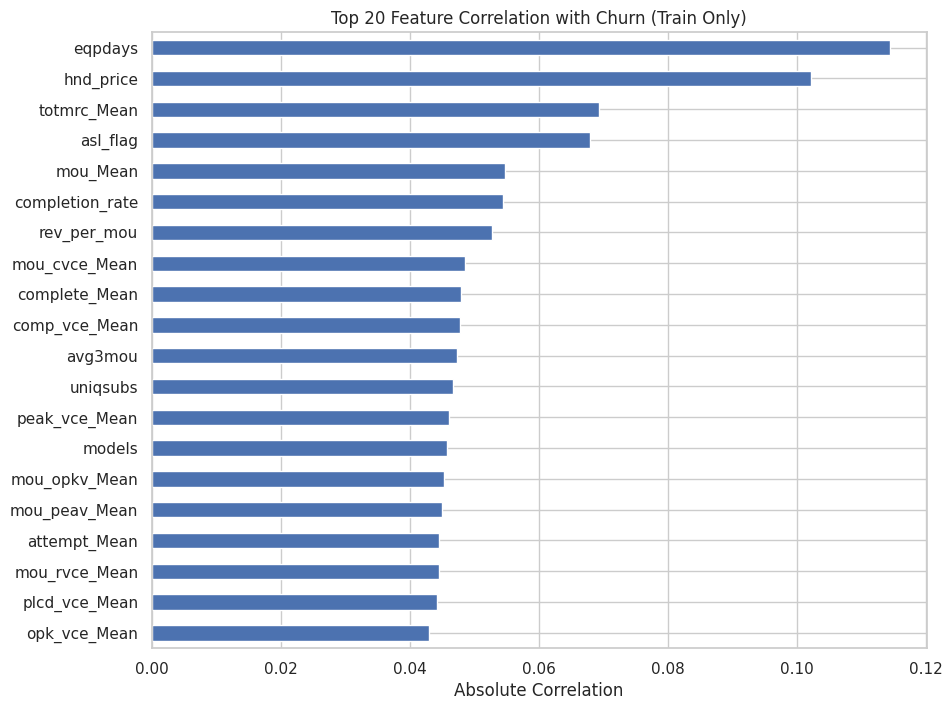

In [63]:
train_eda = X_train.copy()
train_eda[target_col] = y_train.values

eda_encoded = train_eda.copy()
for col in categorical_features:
    eda_encoded[col] = eda_encoded[col].astype('category').cat.codes

corr_to_target = eda_encoded.corr(numeric_only=True)[target_col].abs().sort_values(ascending=False)
top_corr = corr_to_target[1:21]

plt.figure(figsize=(10, 8))
top_corr.sort_values().plot(kind='barh')
plt.title('Top 20 Feature Correlation with Churn (Train Only)')
plt.xlabel('Absolute Correlation')
plt.show()


## 9. Preprocessing pipeline

Imputasi, encoding, dan scaling di-fit hanya pada train.


In [64]:
numeric_pipeline = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('capper', QuantileCapper(
        lower_quantile=CAP_LOWER_QUANTILE,
        upper_quantile=CAP_UPPER_QUANTILE
    )),
    ('scaler', StandardScaler())
])

categorical_pipeline = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('encoder', OneHotEncoder(handle_unknown='ignore'))
])

preprocessor = ColumnTransformer(
    transformers=[
        ('num', numeric_pipeline, numeric_features),
        ('cat', categorical_pipeline, categorical_features),
    ]
)

X_train_prep = preprocessor.fit_transform(X_train)
X_val_prep = preprocessor.transform(X_val)
X_test_prep = preprocessor.transform(X_test)

print('Capping quantiles:', CAP_LOWER_QUANTILE, CAP_UPPER_QUANTILE)
print('X_train_prep:', X_train_prep.shape)
print('X_val_prep:', X_val_prep.shape)
print('X_test_prep:', X_test_prep.shape)


Capping quantiles: 0.005 0.995
X_train_prep: (64000, 210)
X_val_prep: (16000, 210)
X_test_prep: (20000, 210)


## 10. Baseline training tanpa SMOTE

Distribusi target pada train hampir seimbang, jadi SMOTE dan class weight tambahan tidak digunakan agar model tidak terlalu agresif memprediksi churn.


In [65]:
# Target train hampir seimbang, sehingga training memakai data hasil preprocessing asli.
X_train_model = X_train_prep
y_train_model = y_train

print('Distribusi target train:', y_train_model.value_counts().to_dict())
print('X_train_model:', X_train_model.shape)
print('THRESHOLD_STRATEGY:', THRESHOLD_STRATEGY)
print('MIN_PRECISION:', MIN_PRECISION)


def _metrics_at_threshold(y_true, y_pred_proba, threshold):
    y_pred = (y_pred_proba >= threshold).astype(int)
    return {
        'threshold': float(threshold),
        'accuracy': accuracy_score(y_true, y_pred),
        'precision': precision_score(y_true, y_pred, zero_division=0),
        'recall': recall_score(y_true, y_pred, zero_division=0),
        'f1': f1_score(y_true, y_pred, zero_division=0),
    }


def find_best_threshold(y_true, y_pred_proba):
    precision, recall, thresholds = precision_recall_curve(y_true, y_pred_proba)
    f1_scores = 2 * (precision * recall) / (precision + recall + 1e-10)
    best_idx = np.argmax(f1_scores)
    return thresholds[best_idx] if best_idx < len(thresholds) else 0.5


def find_threshold_with_min_precision(y_true, y_pred_proba, min_precision=MIN_PRECISION):
    precision, recall, thresholds = precision_recall_curve(y_true, y_pred_proba)
    candidates = [
        (p, r, t)
        for p, r, t in zip(precision[:-1], recall[:-1], thresholds)
        if p >= min_precision
    ]
    if not candidates:
        return find_best_threshold(y_true, y_pred_proba)
    return max(candidates, key=lambda item: item[1])[2]


def build_threshold_table(y_true, y_pred_proba):
    rows = []
    rows.append({'strategy': 'default_0_5', **_metrics_at_threshold(y_true, y_pred_proba, 0.5)})

    best_f1_threshold = find_best_threshold(y_true, y_pred_proba)
    rows.append({'strategy': 'max_f1', **_metrics_at_threshold(y_true, y_pred_proba, best_f1_threshold)})

    for target in PRECISION_TARGETS:
        threshold = find_threshold_with_min_precision(y_true, y_pred_proba, target)
        rows.append({
            'strategy': f'min_precision_{target:.2f}',
            **_metrics_at_threshold(y_true, y_pred_proba, threshold)
        })

    return pd.DataFrame(rows)


def select_threshold(y_true, y_pred_proba):
    if THRESHOLD_STRATEGY == 'default_0_5':
        return 0.5
    if THRESHOLD_STRATEGY == 'max_f1':
        return find_best_threshold(y_true, y_pred_proba)
    if THRESHOLD_STRATEGY == 'min_precision':
        return find_threshold_with_min_precision(y_true, y_pred_proba, MIN_PRECISION)
    raise ValueError(f'THRESHOLD_STRATEGY tidak dikenal: {THRESHOLD_STRATEGY}')


threshold_tables = {}


Distribusi target train: {0: 32280, 1: 31720}
X_train_model: (64000, 210)
THRESHOLD_STRATEGY: min_precision
MIN_PRECISION: 0.65


SMOTE tidak digunakan karena distribusi target pada data training relatif seimbang. Jika SMOTE tetap dipaksakan pada data yang
sudah cukup seimbang, model berisiko terlalu agresif memprediksi churn sehingga recall meningkat tetapi precision turun. Oleh
karena itu, training menggunakan data asli setelah preprocessing agar model belajar dari distribusi data yang lebih realistis.

## 11. LightGBM baseline + early stopping pada validation set


In [66]:
lgb_model = LGBMClassifier(
    objective='binary',
    metric='auc',
    boosting_type='gbdt',
    num_leaves=31,
    learning_rate=0.03,
    colsample_bytree=0.8,
    subsample=0.8,
    subsample_freq=5,
    n_estimators=1500,
    random_state=RANDOM_STATE,
    n_jobs=-1,
    verbose=-1
)

lgb_model.fit(
    X_train_model,
    y_train_model,
    eval_set=[(X_val_prep, y_val)],
    callbacks=[lgb.early_stopping(stopping_rounds=80, verbose=False)]
)

y_val_proba_lgb = lgb_model.predict_proba(X_val_prep)[:, 1]
threshold_tables['LightGBM'] = build_threshold_table(y_val, y_val_proba_lgb)
optimal_threshold_lgb = select_threshold(y_val, y_val_proba_lgb)

print('Threshold LightGBM:', optimal_threshold_lgb)
display(threshold_tables['LightGBM'])


Threshold LightGBM: 0.5113269203547121


,strategy,threshold,accuracy,precision,recall,f1
0,default_0_5,0.500000,0.643437,0.640272,0.640353,0.640313
1,max_f1,0.354956,0.609250,0.568067,0.882976,0.691351
2,min_precision_0.60,0.431578,0.631687,0.600000,0.770618,0.674689
3,min_precision_0.63,0.483850,0.642500,0.630061,0.675032,0.651772
4,min_precision_0.65,0.511327,0.645437,0.650007,0.616646,0.632887
5,min_precision_0.70,0.584967,0.629938,0.700060,0.443253,0.542815


## 12. Feature selection dari model train


In [67]:
selector = SelectFromModel(lgb_model, threshold='median', prefit=True)
X_train_sel = selector.transform(X_train_model)
X_val_sel = selector.transform(X_val_prep)
X_test_sel = selector.transform(X_test_prep)

try:
    feature_names = preprocessor.get_feature_names_out()
    selected_feature_names = feature_names[selector.get_support()]
    print('Jumlah fitur terpilih:', len(selected_feature_names))
    print(selected_feature_names[:20])
except Exception as e:
    selected_feature_names = None
    print('Nama fitur tidak tersedia:', e)

print('X_train_sel:', X_train_sel.shape)
print('X_val_sel:', X_val_sel.shape)
print('X_test_sel:', X_test_sel.shape)


Nama fitur tidak tersedia: Estimator capper does not provide get_feature_names_out. Did you mean to call pipeline[:-1].get_feature_names_out()?
X_train_sel: (64000, 105)
X_val_sel: (16000, 105)
X_test_sel: (20000, 105)


## 13. Fungsi bantu evaluasi


In [68]:
def evaluate_model(y_true, y_pred, y_pred_proba, model_name):
    roc_auc = roc_auc_score(y_true, y_pred_proba)
    precision, recall, _ = precision_recall_curve(y_true, y_pred_proba)
    pr_auc = auc(recall, precision)

    print(f'{model_name} Evaluation')
    print(classification_report(y_true, y_pred))

    cm = confusion_matrix(y_true, y_pred)
    plt.figure(figsize=(6, 5))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=['Not Churn', 'Churn'],
                yticklabels=['Not Churn', 'Churn'])
    plt.title(f'{model_name} - Confusion Matrix')
    plt.xlabel('Predicted')
    plt.ylabel('Actual')
    plt.show()

    fpr, tpr, _ = roc_curve(y_true, y_pred_proba)
    plt.figure(figsize=(6, 5))
    plt.plot(fpr, tpr, label=f'AUC = {roc_auc:.3f}')
    plt.plot([0, 1], [0, 1], 'k--')
    plt.title(f'{model_name} - ROC Curve')
    plt.xlabel('False Positive Rate')
    plt.ylabel('True Positive Rate')
    plt.legend(loc='lower right')
    plt.show()

    plt.figure(figsize=(6, 5))
    plt.plot(recall, precision, label=f'PR AUC = {pr_auc:.3f}')
    plt.title(f'{model_name} - Precision Recall Curve')
    plt.xlabel('Recall')
    plt.ylabel('Precision')
    plt.legend(loc='lower left')
    plt.show()

    return {
        'model': model_name,
        'accuracy': accuracy_score(y_true, y_pred),
        'precision': precision_score(y_true, y_pred, zero_division=0),
        'recall': recall_score(y_true, y_pred, zero_division=0),
        'f1': f1_score(y_true, y_pred, zero_division=0),
        'roc_auc': roc_auc,
        'pr_auc': pr_auc,
    }


## 14. Modeling dan perbandingan model

Semua threshold ditentukan di validation set dengan target precision minimal, lalu dipakai untuk evaluasi final di test set.


In [69]:
results = []


LightGBM Evaluation
              precision    recall  f1-score   support

           0       0.64      0.66      0.65     10088
           1       0.64      0.61      0.63      9912

    accuracy                           0.64     20000
   macro avg       0.64      0.64      0.64     20000
weighted avg       0.64      0.64      0.64     20000



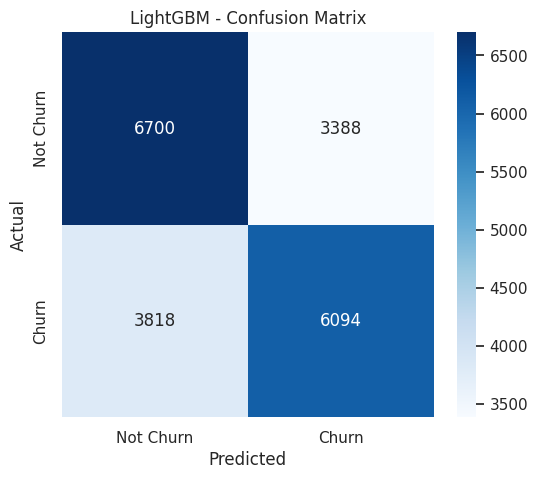

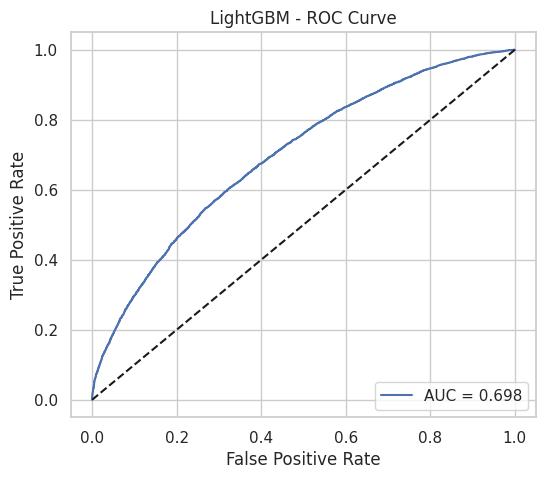

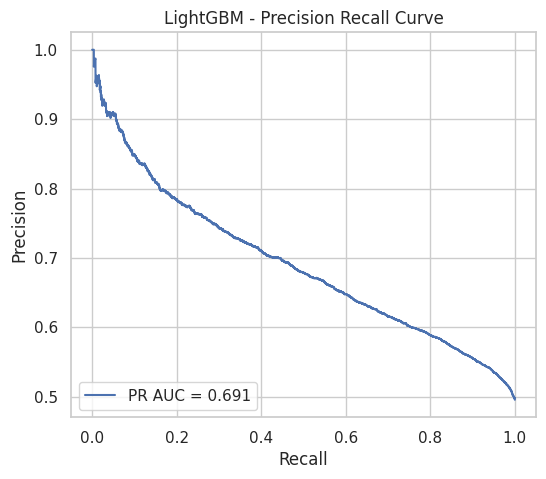

In [70]:
# LightGBM final

y_test_proba_lgb = lgb_model.predict_proba(X_test_prep)[:, 1]
y_test_pred_lgb = (y_test_proba_lgb >= optimal_threshold_lgb).astype(int)
results.append(evaluate_model(y_test, y_test_pred_lgb, y_test_proba_lgb, 'LightGBM'))


XGBoost Evaluation
              precision    recall  f1-score   support

           0       0.63      0.68      0.65     10088
           1       0.65      0.60      0.62      9912

    accuracy                           0.64     20000
   macro avg       0.64      0.64      0.64     20000
weighted avg       0.64      0.64      0.64     20000



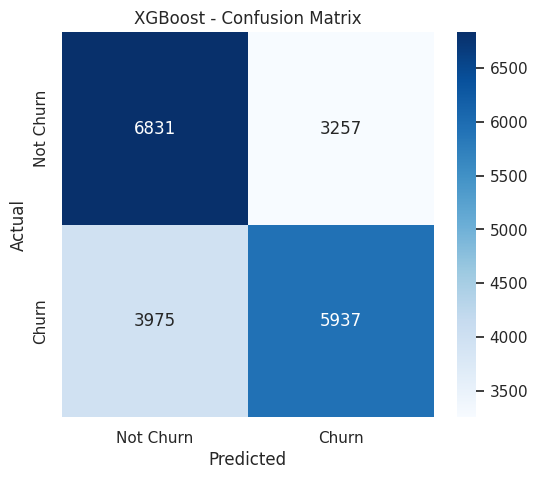

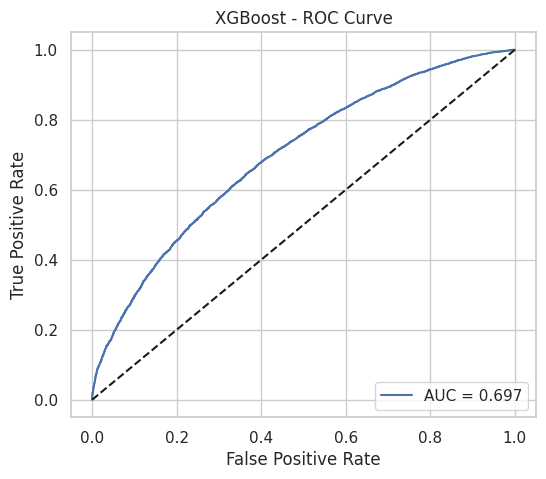

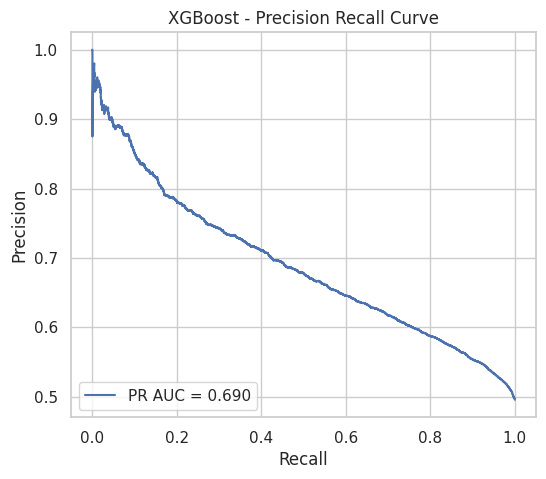

In [71]:
# XGBoost
xgb_model = xgb.XGBClassifier(
    learning_rate=0.05,
    n_estimators=500,
    max_depth=4,
    min_child_weight=3,
    subsample=0.8,
    colsample_bytree=0.8,
    reg_lambda=2.0,
    random_state=RANDOM_STATE,
    eval_metric='auc',
    tree_method='hist',
    n_jobs=-1
)

xgb_model.fit(X_train_sel, y_train_model)
y_val_proba_xgb = xgb_model.predict_proba(X_val_sel)[:, 1]
threshold_tables['XGBoost'] = build_threshold_table(y_val, y_val_proba_xgb)
optimal_threshold_xgb = select_threshold(y_val, y_val_proba_xgb)
y_test_proba_xgb = xgb_model.predict_proba(X_test_sel)[:, 1]
y_test_pred_xgb = (y_test_proba_xgb >= optimal_threshold_xgb).astype(int)
results.append(evaluate_model(y_test, y_test_pred_xgb, y_test_proba_xgb, 'XGBoost'))


Random Forest Evaluation
              precision    recall  f1-score   support

           0       0.60      0.71      0.65     10088
           1       0.64      0.52      0.57      9912

    accuracy                           0.62     20000
   macro avg       0.62      0.62      0.61     20000
weighted avg       0.62      0.62      0.61     20000



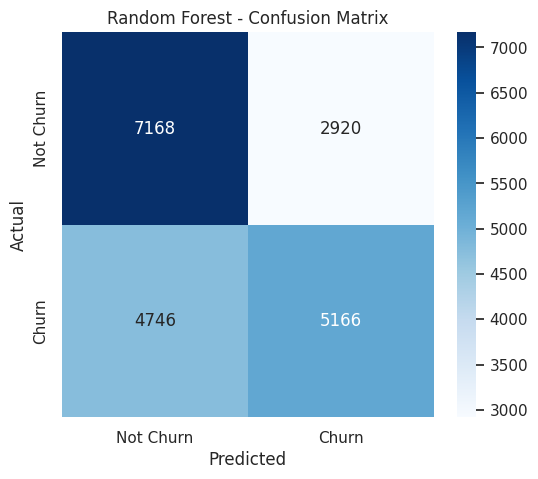

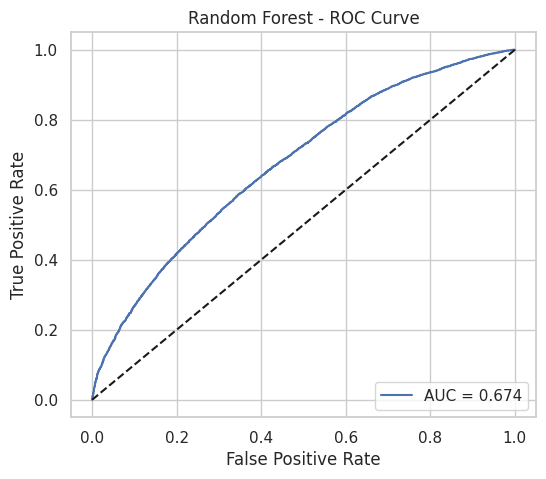

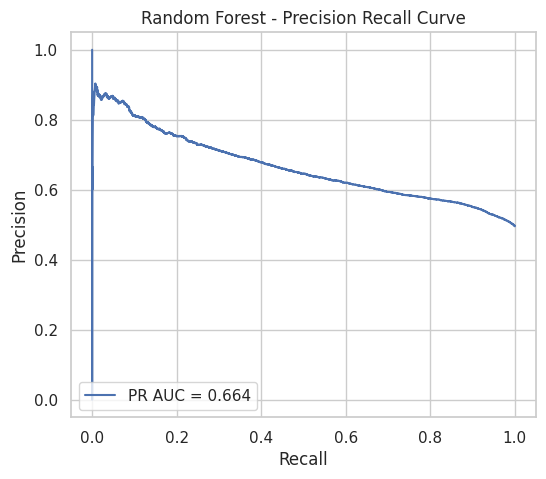

In [72]:
# Random Forest
rf_model = RandomForestClassifier(
    n_estimators=300,
    max_depth=10,
    min_samples_split=8,
    min_samples_leaf=4,
    max_features='sqrt',
    bootstrap=True,
    random_state=RANDOM_STATE,
    n_jobs=-1
)

rf_model.fit(X_train_sel, y_train_model)
y_val_proba_rf = rf_model.predict_proba(X_val_sel)[:, 1]
threshold_tables['Random Forest'] = build_threshold_table(y_val, y_val_proba_rf)
optimal_threshold_rf = select_threshold(y_val, y_val_proba_rf)
y_test_proba_rf = rf_model.predict_proba(X_test_sel)[:, 1]
y_test_pred_rf = (y_test_proba_rf >= optimal_threshold_rf).astype(int)
results.append(evaluate_model(y_test, y_test_pred_rf, y_test_proba_rf, 'Random Forest'))


Logistic Regression Evaluation
              precision    recall  f1-score   support

           0       0.56      0.82      0.66     10088
           1       0.65      0.34      0.44      9912

    accuracy                           0.58     20000
   macro avg       0.60      0.58      0.55     20000
weighted avg       0.60      0.58      0.55     20000



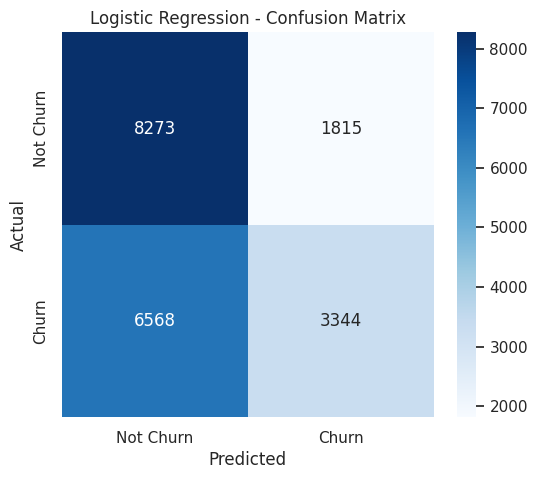

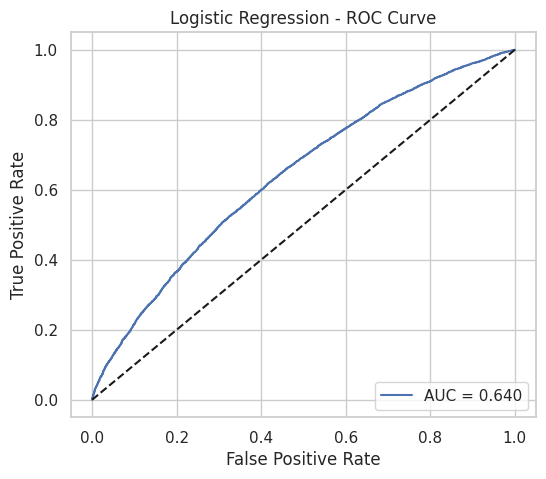

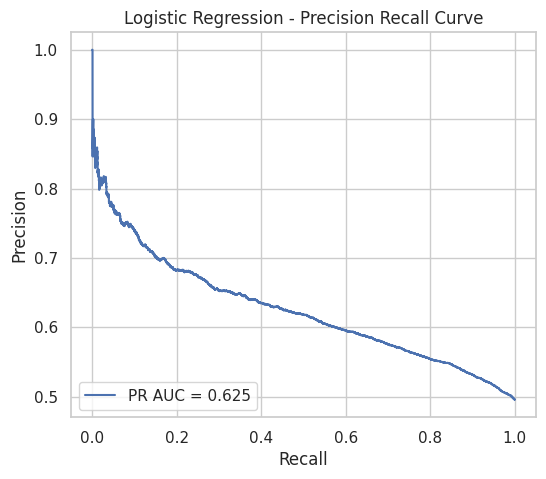

In [73]:
# Logistic Regression
lr_model = LogisticRegression(
    penalty='l2',
    C=1.0,
    solver='liblinear',
    random_state=RANDOM_STATE,
    max_iter=1000
)

lr_model.fit(X_train_sel, y_train_model)
y_val_proba_lr = lr_model.predict_proba(X_val_sel)[:, 1]
threshold_tables['Logistic Regression'] = build_threshold_table(y_val, y_val_proba_lr)
optimal_threshold_lr = select_threshold(y_val, y_val_proba_lr)
y_test_proba_lr = lr_model.predict_proba(X_test_sel)[:, 1]
y_test_pred_lr = (y_test_proba_lr >= optimal_threshold_lr).astype(int)
results.append(evaluate_model(y_test, y_test_pred_lr, y_test_proba_lr, 'Logistic Regression'))


CatBoost Evaluation
              precision    recall  f1-score   support

           0       0.63      0.68      0.66     10088
           1       0.65      0.60      0.62      9912

    accuracy                           0.64     20000
   macro avg       0.64      0.64      0.64     20000
weighted avg       0.64      0.64      0.64     20000



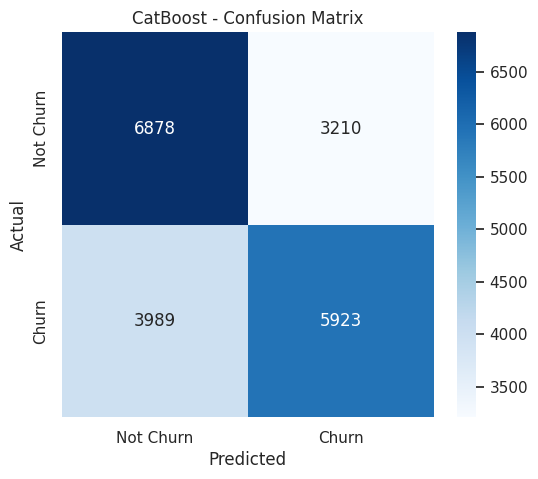

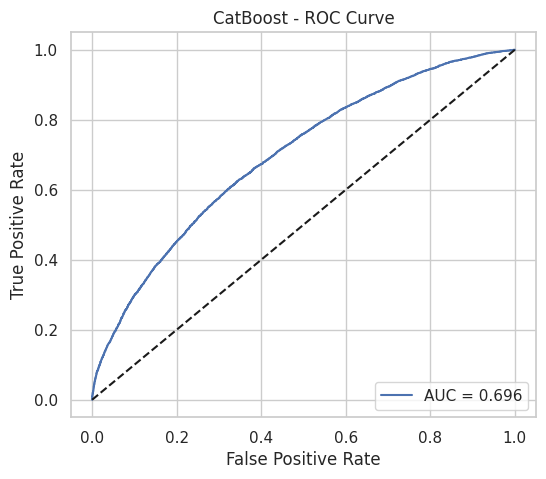

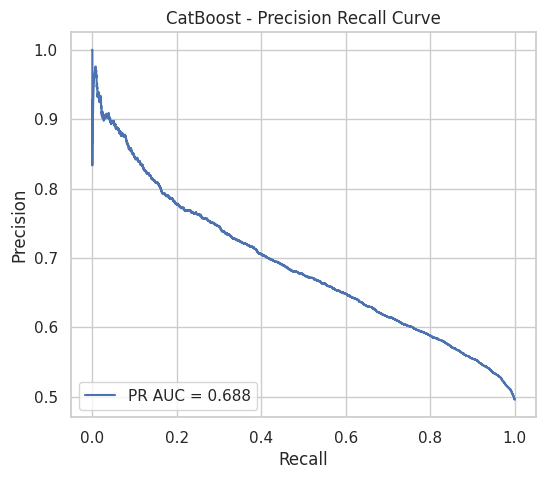

In [74]:
# CatBoost
catboost_model = CatBoostClassifier(
    iterations=700,
    learning_rate=0.04,
    depth=5,
    l2_leaf_reg=5,
    loss_function='Logloss',
    eval_metric='AUC',
    random_seed=RANDOM_STATE,
    verbose=False
)

catboost_model.fit(X_train_sel, y_train_model)
y_val_proba_cat = catboost_model.predict_proba(X_val_sel)[:, 1]
threshold_tables['CatBoost'] = build_threshold_table(y_val, y_val_proba_cat)
optimal_threshold_cat = select_threshold(y_val, y_val_proba_cat)
y_test_proba_cat = catboost_model.predict_proba(X_test_sel)[:, 1]
y_test_pred_cat = (y_test_proba_cat >= optimal_threshold_cat).astype(int)
results.append(evaluate_model(y_test, y_test_pred_cat, y_test_proba_cat, 'CatBoost'))


In [75]:
results

[{'model': 'LightGBM',
  'accuracy': 0.6397,
  'precision': 0.642691415313225,
  'recall': 0.6148103309120259,
  'f1': 0.6284417861194184,
  'roc_auc': np.float64(0.6977416631143917),
  'pr_auc': np.float64(0.6907528440557289)},
 {'model': 'XGBoost',
  'accuracy': 0.6384,
  'precision': 0.645747226452034,
  'recall': 0.5989709443099274,
  'f1': 0.6214801632994871,
  'roc_auc': np.float64(0.6967145085715437),
  'pr_auc': np.float64(0.6896201148116465)},
 {'model': 'Random Forest',
  'accuracy': 0.6167,
  'precision': 0.6388820183032402,
  'recall': 0.5211864406779662,
  'f1': 0.574063784864985,
  'roc_auc': np.float64(0.6742503239450862),
  'pr_auc': np.float64(0.6638857667849214)},
 {'model': 'Logistic Regression',
  'accuracy': 0.58085,
  'precision': 0.6481876332622601,
  'recall': 0.33736884584342214,
  'f1': 0.4437661734456904,
  'roc_auc': np.float64(0.6398159673485114),
  'pr_auc': np.float64(0.6251570050185695)},
 {'model': 'CatBoost',
  'accuracy': 0.64005,
  'precision': 0.648

Pada tahap modeling, beberapa algoritma diuji untuk membandingkan performa secara objektif. Model yang digunakan mencakup Logistic
Regression, Random Forest, XGBoost, LightGBM, CatBoost, XGBoost Tuned, dan Stacking Ensemble. Logistic Regression digunakan sebagai
baseline sederhana, sedangkan Random Forest dan model boosting digunakan karena lebih mampu menangkap pola non-linear pada data tabular.


Berdasarkan hasil evaluasi, Logistic Regression memiliki performa paling rendah dengan F1-score sekitar 0.4438 dan ROC-AUC sekitar
0.6398. Hal ini menunjukkan bahwa hubungan antarfitur dan target churn kemungkinan tidak sepenuhnya linear, sehingga model linear
kurang mampu menangkap pola churn secara optimal.


Random Forest memberikan peningkatan dibanding Logistic Regression, tetapi performanya masih berada di bawah model boosting. Model
boosting seperti XGBoost, LightGBM, dan CatBoost memberikan hasil yang lebih stabil, dengan F1-score berada di sekitar 0.62 dan
ROC-AUC mendekati 0.70. Ini menunjukkan bahwa algoritma boosting lebih sesuai untuk dataset ini karena mampu mempelajari interaksi
fitur dan pola non-linear dengan lebih baik.


Pada hasil test set, LightGBM memiliki F1-score tertinggi di antara model individual, yaitu sekitar 0.6284. Namun, Stacking
Ensemble memiliki accuracy, ROC-AUC, dan PR-AUC yang sedikit lebih tinggi secara keseluruhan. Perbedaan performa antar model
terbaik relatif kecil, sehingga pemilihan model akhir perlu mempertimbangkan tujuan bisnis, bukan hanya satu metrik saja.

## 15. Hyperparameter tuning XGBoost dengan cross-validation pada train saja

Tuning diarahkan ke `average_precision` agar performa ranking churn lebih selaras dengan PR-AUC dan precision.


In [76]:
def objective(trial):
    params = {
        'n_estimators': trial.suggest_int('n_estimators', 200, 600),
        'max_depth': trial.suggest_int('max_depth', 3, 5),
        'learning_rate': trial.suggest_float('learning_rate', 0.02, 0.12),
        'subsample': trial.suggest_float('subsample', 0.75, 1.0),
        'colsample_bytree': trial.suggest_float('colsample_bytree', 0.75, 1.0),
        'min_child_weight': trial.suggest_int('min_child_weight', 2, 8),
        'reg_lambda': trial.suggest_float('reg_lambda', 2.0, 8.0),
        'random_state': RANDOM_STATE,
        'eval_metric': 'auc',
        'tree_method': 'hist',
        'n_jobs': 1,
    }
    model = xgb.XGBClassifier(**params)
    cv = StratifiedKFold(n_splits=CV_FOLDS, shuffle=True, random_state=RANDOM_STATE)
    return cross_val_score(model, X_train_sel, y_train_model, cv=cv, scoring='average_precision', n_jobs=-1).mean()

study = optuna.create_study(direction='maximize')
study.optimize(objective, n_trials=N_TRIALS, timeout=OPTUNA_TIMEOUT)
print('Best params:', study.best_params)
print('Best CV average precision:', study.best_value)


[I 2026-05-14 13:13:58,301] A new study created in memory with name: no-name-a60ba322-9ac0-4647-8a44-37b6a0eebbe0
[I 2026-05-14 13:14:26,688] Trial 0 finished with value: 0.6836811325670196 and parameters: {'n_estimators': 497, 'max_depth': 4, 'learning_rate': 0.10165588759890999, 'subsample': 0.7545672765306948, 'colsample_bytree': 0.7705251727423343, 'min_child_weight': 7, 'reg_lambda': 6.202943917935225}. Best is trial 0 with value: 0.6836811325670196.
[I 2026-05-14 13:14:54,674] Trial 1 finished with value: 0.6859027801417902 and parameters: {'n_estimators': 496, 'max_depth': 4, 'learning_rate': 0.05884289252812103, 'subsample': 0.967394128971055, 'colsample_bytree': 0.9094815631258416, 'min_child_weight': 5, 'reg_lambda': 6.549819879117225}. Best is trial 1 with value: 0.6859027801417902.
[I 2026-05-14 13:15:06,998] Trial 2 finished with value: 0.6821827368246597 and parameters: {'n_estimators': 260, 'max_depth': 3, 'learning_rate': 0.09497057026389209, 'subsample': 0.922713982766

Best params: {'n_estimators': 591, 'max_depth': 5, 'learning_rate': 0.03629556148654272, 'subsample': 0.9336065423289093, 'colsample_bytree': 0.8964075723849245, 'min_child_weight': 4, 'reg_lambda': 5.722265987400242}
Best CV average precision: 0.6875613695163646


XGBoost Tuned Evaluation
              precision    recall  f1-score   support

           0       0.63      0.68      0.65     10088
           1       0.65      0.60      0.62      9912

    accuracy                           0.64     20000
   macro avg       0.64      0.64      0.64     20000
weighted avg       0.64      0.64      0.64     20000



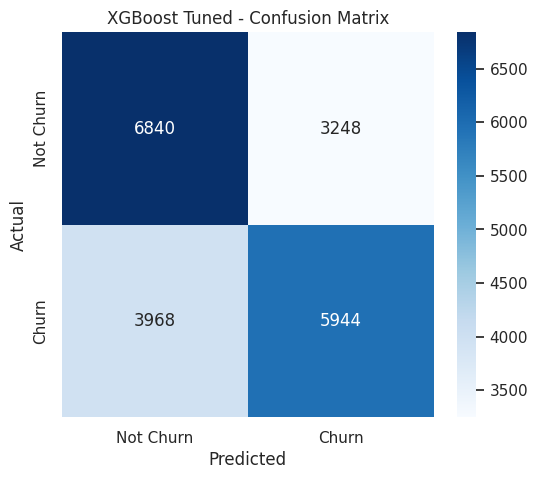

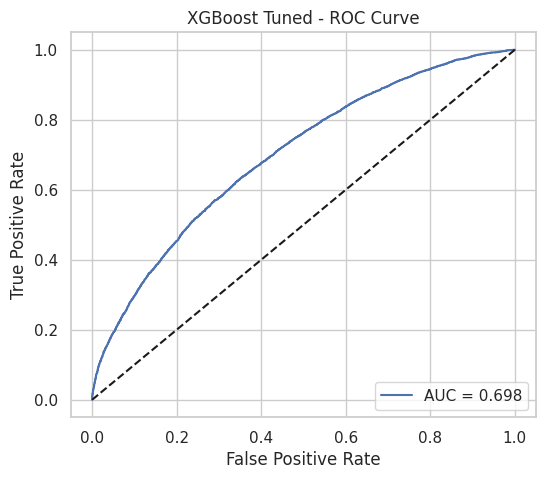

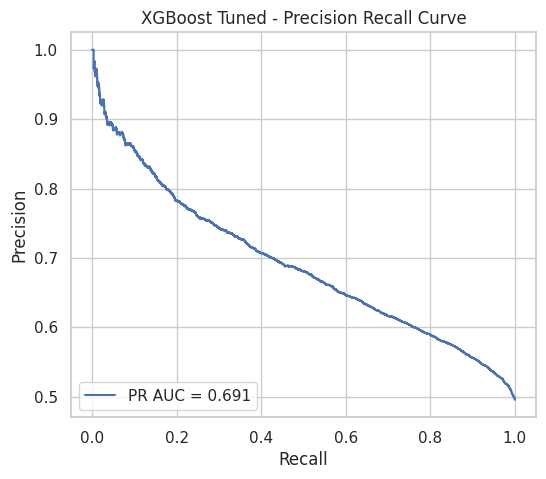

In [77]:
best_params = study.best_params.copy()
xgb_tuned_model = xgb.XGBClassifier(
    **best_params,
    random_state=RANDOM_STATE,
    eval_metric='auc',
    tree_method='hist',
    n_jobs=-1
)

xgb_tuned_model.fit(X_train_sel, y_train_model)
y_val_proba_tuned = xgb_tuned_model.predict_proba(X_val_sel)[:, 1]
threshold_tables['XGBoost Tuned'] = build_threshold_table(y_val, y_val_proba_tuned)
optimal_threshold_tuned = select_threshold(y_val, y_val_proba_tuned)
y_test_proba_tuned = xgb_tuned_model.predict_proba(X_test_sel)[:, 1]
y_test_pred_tuned = (y_test_proba_tuned >= optimal_threshold_tuned).astype(int)
results.append(evaluate_model(y_test, y_test_pred_tuned, y_test_proba_tuned, 'XGBoost Tuned'))


Hyperparameter tuning dilakukan pada XGBoost untuk mencari kombinasi parameter yang lebih optimal dibandingkan konfigurasi default.
Proses tuning menggunakan cross-validation pada data train agar evaluasi parameter lebih stabil dan tidak hanya bergantung pada satu pembagian data.

Metrik optimasi diarahkan ke `average_precision` karena kasus churn prediction tidak hanya membutuhkan akurasi, tetapi juga kemampuan model dalam memberi ranking pelanggan berdasarkan risiko churn. PR-AUC atau average precision lebih relevan ketika organisasi ingin memprioritaskan pelanggan dengan probabilitas churn tinggi.

Hasil tuning menunjukkan adanya peningkatan kecil dibanding XGBoost default. XGBoost default memperoleh accuracy sekitar 0.6384, F1-score sekitar 0.6215, ROC-AUC sekitar 0.6967, dan PR-AUC sekitar 0.6896. Setelah tuning, XGBoost Tuned memperoleh accuracy sekitar 0.6392, F1-score sekitar 0.6223, ROC-AUC sekitar 0.6981, dan PR-AUC sekitar 0.6907.

Peningkatannya memang tidak terlalu besar, tetapi tuning tetap penting karena menunjukkan adanya proses eksperimen sistematis untuk mencari model terbaik. Hasil ini juga menunjukkan bahwa performa XGBoost sudah cukup stabil sejak konfigurasi awal, sehingga tuning hanya memberikan perbaikan marginal.

## 16. Ensemble stacking


Stacking Ensemble Evaluation
              precision    recall  f1-score   support

           0       0.64      0.67      0.65     10088
           1       0.65      0.61      0.63      9912

    accuracy                           0.64     20000
   macro avg       0.64      0.64      0.64     20000
weighted avg       0.64      0.64      0.64     20000



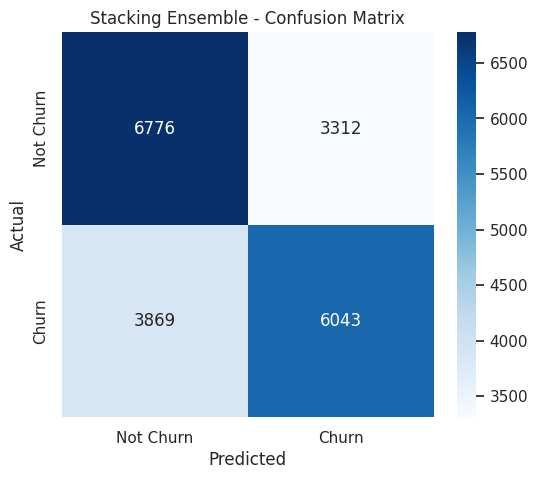

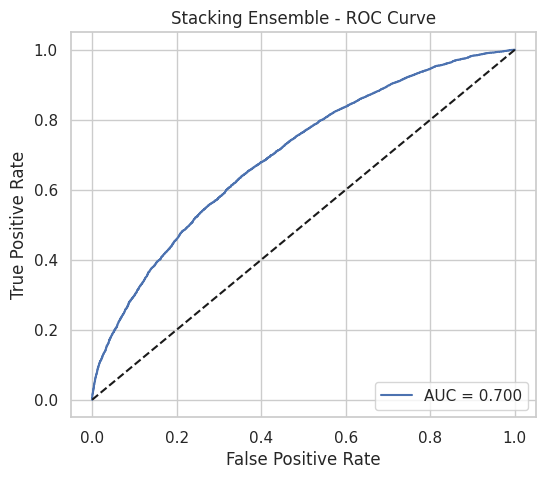

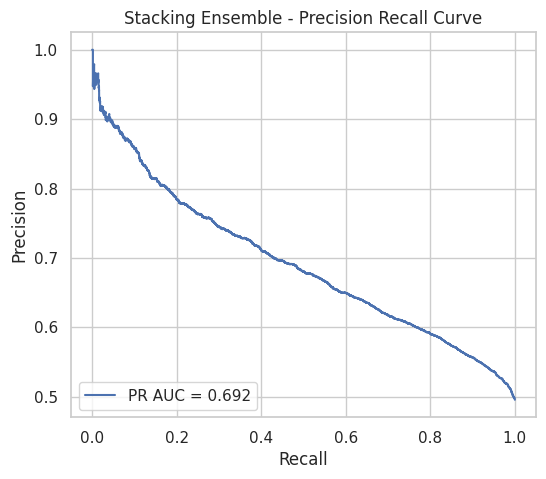

In [78]:
estimators = [
    ('xgb', xgb_tuned_model),
    ('lgb', lgb_model),
    ('cat', catboost_model),
]

stack = StackingClassifier(
    estimators=estimators,
    final_estimator=LogisticRegression(max_iter=1000),
    n_jobs=-1
)

stack.fit(X_train_sel, y_train_model)
y_val_proba_stack = stack.predict_proba(X_val_sel)[:, 1]
threshold_tables['Stacking Ensemble'] = build_threshold_table(y_val, y_val_proba_stack)
optimal_threshold_stack = select_threshold(y_val, y_val_proba_stack)
y_test_proba_stack = stack.predict_proba(X_test_sel)[:, 1]
y_test_pred_stack = (y_test_proba_stack >= optimal_threshold_stack).astype(int)
results.append(evaluate_model(y_test, y_test_pred_stack, y_test_proba_stack, 'Stacking Ensemble'))


Stacking Ensemble digunakan untuk menggabungkan beberapa model dasar agar prediksi akhir tidak bergantung pada satu algoritma saja.
Dalam pendekatan ini, prediksi dari beberapa model digunakan sebagai input bagi model akhir. Tujuannya adalah memanfaatkan
kelebihan masing-masing model dan menghasilkan prediksi yang lebih stabil.

Berdasarkan hasil evaluasi, Stacking Ensemble memperoleh accuracy sekitar 0.64095, precision sekitar 0.6460, recall sekitar 0.6097,
F1-score sekitar 0.6273, ROC-AUC sekitar 0.6996, dan PR-AUC sekitar 0.6919. Nilai ROC-AUC dan PR-AUC ini menjadi yang tertinggi
dibandingkan model lain, sehingga Stacking Ensemble dapat dianggap sebagai model terbaik secara keseluruhan jika fokusnya adalah stabilitas performa dan kemampuan ranking risiko churn.

Namun, jika fokus utama adalah F1-score, LightGBM sedikit lebih unggul dengan F1-score sekitar 0.6284. Selisihnya sangat kecil,
sehingga keduanya masih termasuk kandidat model terbaik. Stacking Ensemble lebih kuat dari sisi performa agregat, sedangkan LightGBM lebih sederhana dan lebih mudah dijelaskan/deploy.

Dengan mempertimbangkan hasil tersebut, Stacking Ensemble dapat dipilih sebagai model final jika tujuan utama adalah performa keseluruhan. Namun, LightGBM dapat menjadi alternatif yang baik jika prioritasnya adalah model yang lebih ringan, cepat, dan mudah diinterpretasikan.

## 17. Ringkasan hasil


In [87]:
results_df = pd.DataFrame(results).sort_values(by=['accuracy', 'f1', 'roc_auc', 'pr_auc'], ascending=False)
results_df


,model,accuracy,precision,recall,f1,roc_auc,pr_auc
6,Stacking Ensemble,0.64095,0.645965,0.609665,0.627290,0.699551,0.691927
4,CatBoost,0.64005,0.648527,0.597559,0.622001,0.696087,0.688090
0,LightGBM,0.63970,0.642691,0.614810,0.628442,0.697742,0.690753
5,XGBoost Tuned,0.63920,0.646649,0.599677,0.622278,0.698115,0.690682
1,XGBoost,0.63840,0.645747,0.598971,0.621480,0.696715,0.689620
2,Random Forest,0.61670,0.638882,0.521186,0.574064,0.674250,0.663886
3,Logistic Regression,0.58085,0.648188,0.337369,0.443766,0.639816,0.625157


Model Stacking Ensemble merupakan model dengan performa paling baik jika dibandingkan dengan model-model lain jikalau dilihat dari matriks accuracy, f1, roc_auc, pr_auc (sesuai urutan)

In [80]:
threshold_summary = pd.concat(
    [table.assign(model=model) for model, table in threshold_tables.items()],
    ignore_index=True
)
threshold_summary = threshold_summary[['model', 'strategy', 'threshold', 'accuracy', 'precision', 'recall', 'f1']]
threshold_summary.sort_values(['model', 'strategy'])


,model,strategy,threshold,accuracy,precision,recall,f1
24,CatBoost,default_0_5,0.500000,0.643938,0.640848,0.640605,0.640726
25,CatBoost,max_f1,0.351777,0.596750,0.557501,0.903531,0.689539
26,CatBoost,min_precision_0.60,0.442681,0.631375,0.600000,0.768726,0.673964
27,CatBoost,min_precision_0.63,0.486943,0.641375,0.630012,0.669735,0.649267
28,CatBoost,min_precision_0.65,0.514452,0.641312,0.650048,0.598487,0.623203
29,CatBoost,min_precision_0.70,0.577656,0.624375,0.700083,0.423581,0.527813
0,LightGBM,default_0_5,0.500000,0.643437,0.640272,0.640353,0.640313
1,LightGBM,max_f1,0.354956,0.609250,0.568067,0.882976,0.691351
2,LightGBM,min_precision_0.60,0.431578,0.631687,0.600000,0.770618,0.674689
3,LightGBM,min_precision_0.63,0.483850,0.642500,0.630061,0.675032,0.651772


Evaluasi threshold dilakukan karena output model berupa probabilitas churn, bukan hanya label 0 dan 1. Threshold 0.5 adalah batas standar, tetapi belum tentu paling optimal untuk kebutuhan bisnis. Strategi `max_f1` digunakan untuk mencari keseimbangan terbaik antara precision dan recall, sedangkan strategi `min_precision` digunakan jika perusahaan ingin memastikan bahwa pelanggan yang diprediksi churn benar-benar memiliki risiko tinggi. Dalam konteks bisnis, threshold dapat diatur sesuai biaya intervensi retention

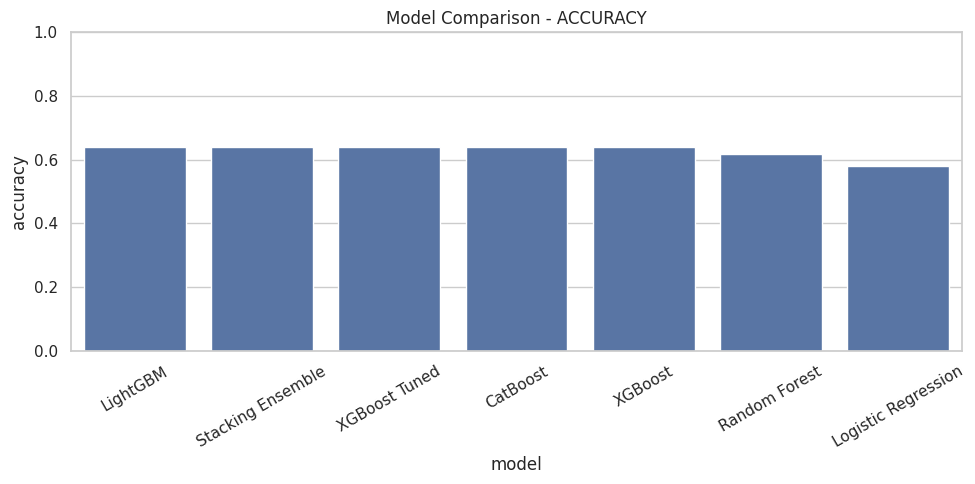

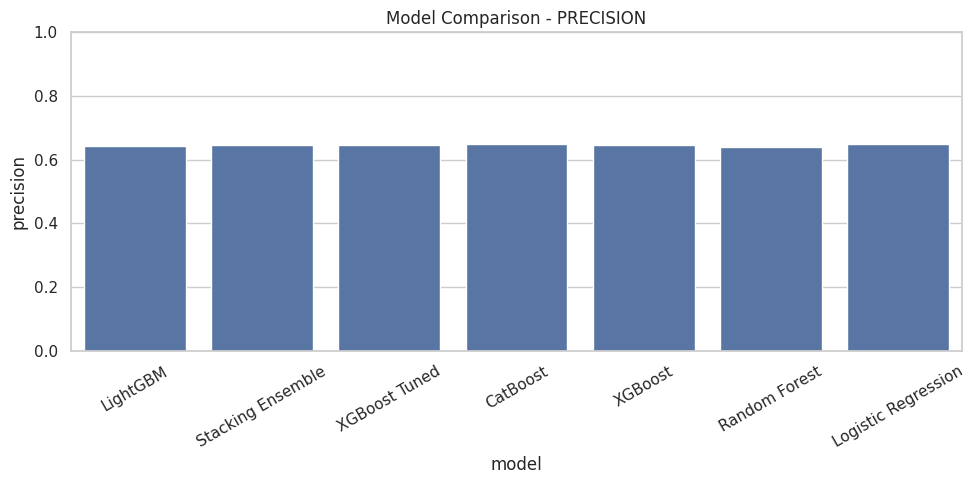

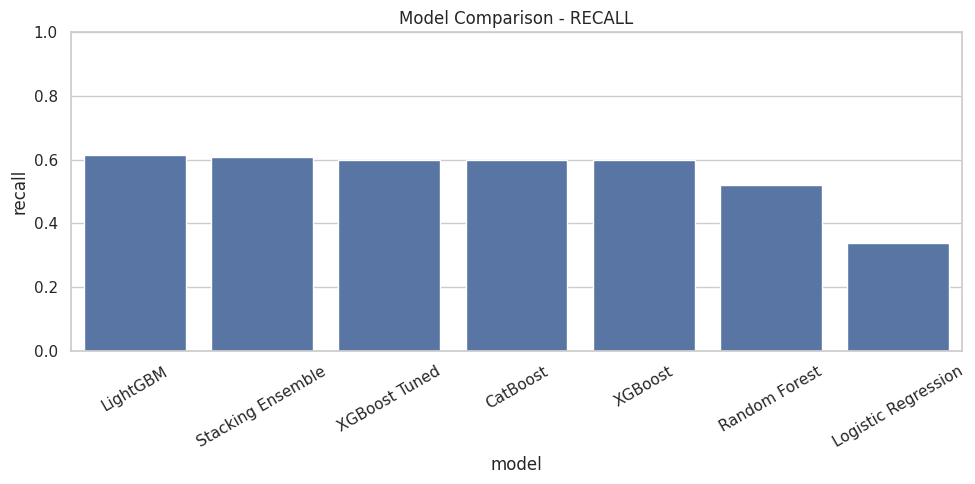

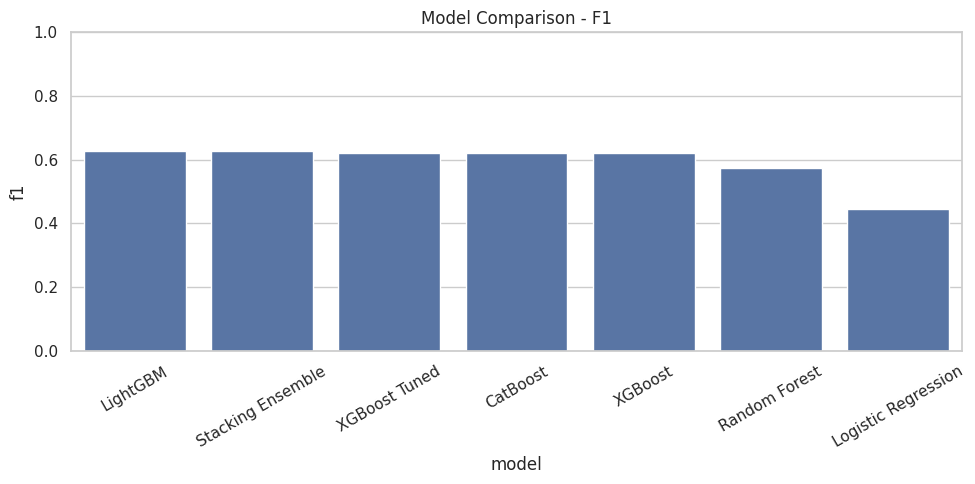

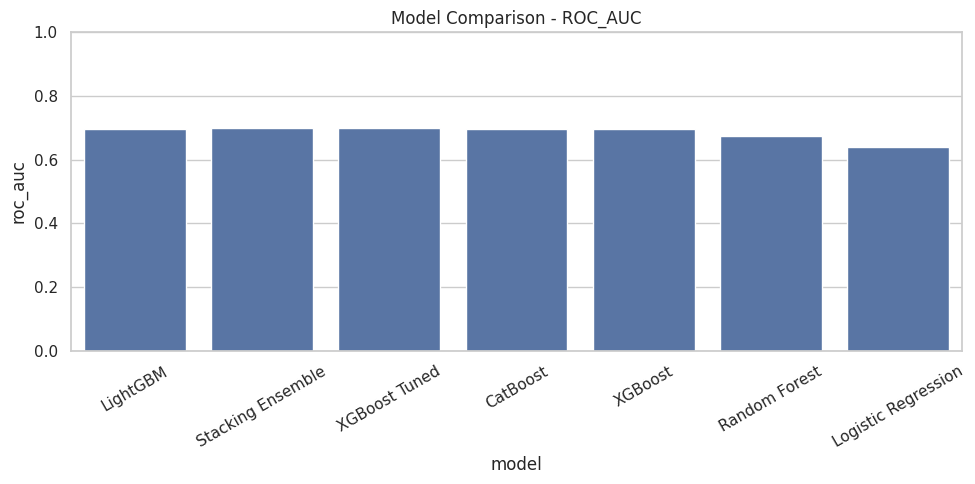

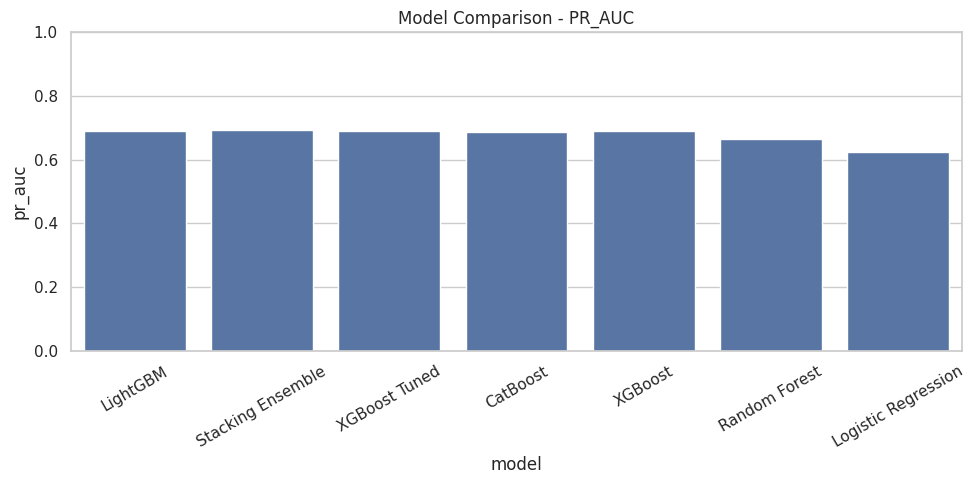

In [81]:
for metric in ['accuracy', 'precision', 'recall', 'f1', 'roc_auc', 'pr_auc']:
    plt.figure(figsize=(10, 5))
    sns.barplot(data=results_df, x='model', y=metric)
    plt.title(f'Model Comparison - {metric.upper()}')
    plt.xticks(rotation=30)
    plt.ylim(0, 1)
    plt.tight_layout()
    plt.show()


Berdasarkan hasil evaluasi pada test set, Stacking Ensemble menjadi model terbaik jika prioritas utama adalah accuracy, ROC-AUC, dan PR-AUC secara keseluruhan. Model ini memperoleh accuracy sekitar 0.64095, precision sekitar 0.64597, recall sekitar 0.60967, F1 sekitar 0.62729, ROC-AUC sekitar 0.69955, dan PR-AUC sekitar 0.69193.

Namun, jika fokus utama adalah F1-score pada threshold yang digunakan saat ini, LightGBM sedikit lebih unggul. Oleh karena itu, pemilihan model akhir perlu disesuaikan dengan tujuan bisnis. Jika perusahaan ingin prediksi yang lebih stabil secara keseluruhan, Stacking Ensemble dapat dipilih. Jika perusahaan lebih fokus pada keseimbangan precision-recall, LightGBM atau strategi threshold `max_f1` dapat dipertimbangkan.

## 18. Simpan artefak model

Simpan preprocessor, selector, model, threshold, dan bundle inference agar deployment tidak kehilangan preprocessing.


In [82]:
os.makedirs('ml/models', exist_ok=True)
joblib.dump(preprocessor, 'ml/models/preprocessor.joblib')
joblib.dump(selector, 'ml/models/selector.joblib')
joblib.dump(lgb_model, 'ml/models/lgb_model.joblib')
joblib.dump(xgb_tuned_model, 'ml/models/xgb_tuned_model.joblib')
joblib.dump(stack, 'ml/models/stack_model.joblib')

thresholds = {
    'lightgbm': float(optimal_threshold_lgb),
    'xgboost': float(optimal_threshold_xgb),
    'random_forest': float(optimal_threshold_rf),
    'logistic_regression': float(optimal_threshold_lr),
    'catboost': float(optimal_threshold_cat),
    'xgboost_tuned': float(optimal_threshold_tuned),
    'stacking': float(optimal_threshold_stack),
    'threshold_strategy': THRESHOLD_STRATEGY,
    'min_precision_target': float(MIN_PRECISION),
}

with open('ml/models/thresholds.json', 'w', encoding='utf-8') as f:
    json.dump(thresholds, f, indent=2)

model_bundle = {
    'preprocessor': preprocessor,
    'selector': selector,
    'model': stack,
    'threshold': float(optimal_threshold_stack),
    'thresholds': thresholds,
    'selected_feature_names': selected_feature_names,
    'numeric_features': numeric_features,
    'categorical_features': categorical_features,
}
joblib.dump(model_bundle, 'ml/models/best_model.joblib')

print('Model artifacts saved to ml/models')
print('Main deployment bundle: ml/models/best_model.joblib')


Model artifacts saved to ml/models
Main deployment bundle: ml/models/best_model.joblib


In [88]:
import pandas as pd
import numpy as np
import joblib
import os

# Load the original dataframe to get Customer_ID
original_df_full = pd.read_csv('/content/drive/MyDrive/Telecom_customer.csv')
all_customer_ids = original_df_full['Customer_ID']

# Load the ensemble model bundle, which is a dictionary
model_bundle = joblib.load('ml/models/best_model.joblib')

# Extract the actual model object, preprocessor, and selector from the bundle
model = model_bundle['model']
preprocessor_loaded = model_bundle['preprocessor']
selector_loaded = model_bundle['selector']

# Prepare the full dataset (X) for prediction using the pre-fitted scaler and selector
# X is the DataFrame containing all features for all 100,000 customers (before splitting and target drop)
X_full_prep = preprocessor_loaded.transform(X)
X_full_sel = selector_loaded.transform(X_full_prep)

# Make predictions using the ensemble model on the transformed full dataset
ml_churn_score = model.predict_proba(X_full_sel)[:, 1]
ml_churn_label = model.predict(X_full_sel)

# Create the scores DataFrame for the full dataset
scores_df = pd.DataFrame({
    "Customer_ID": all_customer_ids,
    "ml_churn_score": ml_churn_score,
    "ml_churn_label": ml_churn_label
})

# Define the path to save the CSV file
output_path = "ml/models/churn_scores.csv"

# Ensure the directory exists
os.makedirs(os.path.dirname(output_path), exist_ok=True)

# Save the DataFrame to a CSV file
scores_df.to_csv(output_path, index=False)

print(f"Predictions for {len(scores_df)} customers saved to {output_path}")

Predictions for 100000 customers saved to ml/models/churn_scores.csv


## 19. Interpretasi bisnis

Model churn prediction ini dapat membantu perusahaan mengidentifikasi pelanggan yang memiliki risiko churn lebih tinggi. Pelanggan
dengan probabilitas churn tinggi dapat diprioritaskan untuk program retensi seperti promo khusus, peningkatan layanan, atau follow-up dari customer service.

Precision menggambarkan seberapa tepat prediksi churn yang diberikan model. Jika precision tinggi, maka pelanggan yang ditandai sebagai churn lebih mungkin benar-benar churn, sehingga biaya intervensi lebih efisien. Recall menggambarkan seberapa banyak pelanggan churn yang berhasil ditemukan oleh model. Jika recall tinggi, maka perusahaan dapat menangkap lebih banyak pelanggan berisiko sebelum mereka benar-benar berhenti menggunakan layanan.

Karena biaya kehilangan pelanggan dan biaya promosi perlu diseimbangkan, penggunaan threshold menjadi penting. Perusahaan dapat memilih threshold yang lebih rendah jika ingin menangkap lebih banyak pelanggan berisiko, atau threshold yang lebih tinggi jika ingin intervensi hanya diberikan kepada pelanggan dengan risiko churn paling kuat.
